### Import basic libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/student habits performance.csv")

In [3]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
df.shape

(1000, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

Since, `student_id` is not contrubating anything so i am removing it.

In [6]:
# Drop student_id
df.drop(columns=["student_id"], inplace = True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   gender                         1000 non-null   object 
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   object 
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   object 
 9   exercise_frequency             1000 non-null   int64  
 10  parental_education_level       909 non-null    object 
 11  internet_quality               1000 non-null   object 
 12  mental_health_rating           1000 non-null   in

---

### Fill missing data

As `parental_education_level` column has some missing values, we need to figure it out what and why. After that remove missing values or fill them.

In [8]:
df['parental_education_level'].isnull().value_counts()

parental_education_level
False    909
True      91
Name: count, dtype: int64

In [9]:
df['parental_education_level'].value_counts()

parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64

In [10]:
df['score_group'] = pd.cut(
    df['exam_score'],
    bins=[0, 50, 70, 85, 100],
    labels=['low', 'medium', 'high', 'very_high']
)

In [11]:
df['parental_education_level'] = df.groupby('score_group')['parental_education_level']\
    .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'High School'))

C:\Users\pradip\AppData\Local\Temp\ipykernel_18256\632490067.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['parental_education_level'] = df.groupby('score_group')['parental_education_level']\


In [12]:
df.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,score_group
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2,medium
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0,very_high
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3,low
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8,low
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4,medium


In [13]:
df.drop(columns = ["score_group"], inplace = True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   gender                         1000 non-null   object 
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   object 
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   object 
 9   exercise_frequency             1000 non-null   int64  
 10  parental_education_level       1000 non-null   object 
 11  internet_quality               1000 non-null   object 
 12  mental_health_rating           1000 non-null   in

---

### Convert categorical data into numeric
1. gender
2. part_time_job
3. diet_quality
4. parental_education_level
5. internet_quality
6. extracurricular_participation

To find the correlation between each others and target veriable as `exam_score`.

In [15]:
df['gender'].value_counts()

gender
Female    481
Male      477
Other      42
Name: count, dtype: int64

In [16]:
df['diet_quality'].value_counts()

diet_quality
Fair    437
Good    378
Poor    185
Name: count, dtype: int64

In [17]:
df['part_time_job'].value_counts()

part_time_job
No     785
Yes    215
Name: count, dtype: int64

In [18]:
df['parental_education_level'].value_counts()

parental_education_level
High School    483
Bachelor       350
Master         167
Name: count, dtype: int64

In [19]:
df['internet_quality'].value_counts()

internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64

In [20]:
df['extracurricular_participation'].value_counts()

extracurricular_participation
No     682
Yes    318
Name: count, dtype: int64

---

## Converting data into numeric terms

In [21]:
# One-Hot encoding
df = pd.get_dummies(df, columns=['gender'])

In [22]:
# Binary encoding
part_time_map = {
    "No": 0,
    "Yes": 1
}

df['part_time_job'] = df['part_time_job'].map(part_time_map)

In [23]:
# Ordered encoding
diet_map = {
    "Poor" : 0,
    "Fair" : 1,
    "Good" : 2,
}

df['diet_quality'] = df['diet_quality'].map(diet_map)

In [24]:
# Ordered encoding
parent_edu_map = {
    "High School": 0,
    "Bachelor": 1,
    "Master": 2
}

df['parental_education_level'] = df['parental_education_level'].map(parent_edu_map)

In [25]:
# Ordered encoding
internet_map = {
    "Poor": 0,
    "Average": 1,
    "Good": 2
}

df['internet_quality'] = df['internet_quality'].map(internet_map)

In [26]:
# Binary encoding
extra_curr_map = {
    "No": 0,
    "Yes": 1
}

df['extracurricular_participation'] = df['extracurricular_participation'].map(extra_curr_map)

In [27]:
df.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,gender_Female,gender_Male,gender_Other
0,23,0.0,1.2,1.1,0,85.0,8.0,1,6,2,1,8,1,56.2,True,False,False
1,20,6.9,2.8,2.3,0,97.3,4.6,2,6,0,1,8,0,100.0,True,False,False
2,21,1.4,3.1,1.3,0,94.8,8.0,0,1,0,0,1,0,34.3,False,True,False
3,23,1.0,3.9,1.0,0,71.0,9.2,0,4,2,2,1,1,26.8,True,False,False
4,19,5.0,4.4,0.5,0,90.9,4.9,1,3,2,2,1,0,66.4,True,False,False


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   study_hours_per_day            1000 non-null   float64
 2   social_media_hours             1000 non-null   float64
 3   netflix_hours                  1000 non-null   float64
 4   part_time_job                  1000 non-null   int64  
 5   attendance_percentage          1000 non-null   float64
 6   sleep_hours                    1000 non-null   float64
 7   diet_quality                   1000 non-null   int64  
 8   exercise_frequency             1000 non-null   int64  
 9   parental_education_level       1000 non-null   int64  
 10  internet_quality               1000 non-null   int64  
 11  mental_health_rating           1000 non-null   int64  
 12  extracurricular_participation  1000 non-null   in

Droping `gender_Other` column because it redice the complexity and if both columns or male and 
female is false means it is others.

In [29]:
df.drop(columns = ['gender_Other'], inplace = True)

In [30]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   study_hours_per_day            1000 non-null   float64
 2   social_media_hours             1000 non-null   float64
 3   netflix_hours                  1000 non-null   float64
 4   part_time_job                  1000 non-null   int64  
 5   attendance_percentage          1000 non-null   float64
 6   sleep_hours                    1000 non-null   float64
 7   diet_quality                   1000 non-null   int64  
 8   exercise_frequency             1000 non-null   int64  
 9   parental_education_level       1000 non-null   int64  
 10  internet_quality               1000 non-null   int64  
 11  mental_health_rating           1000 non-null   int64  
 12  extracurricular_participation  1000 non-null   in

In [32]:
df.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,gender_Female,gender_Male
0,23,0.0,1.2,1.1,0,85.0,8.0,1,6,2,1,8,1,56.2,1,0
1,20,6.9,2.8,2.3,0,97.3,4.6,2,6,0,1,8,0,100.0,1,0
2,21,1.4,3.1,1.3,0,94.8,8.0,0,1,0,0,1,0,34.3,0,1
3,23,1.0,3.9,1.0,0,71.0,9.2,0,4,2,2,1,1,26.8,1,0
4,19,5.0,4.4,0.5,0,90.9,4.9,1,3,2,2,1,0,66.4,1,0


---

## Cleane Numerical data
Now i have all the data in Numerical terms. Now i can plot a correlation map,
and check which features are contributing more and which are just increaseing numbers. After the i'll
remove those featuers.

In [33]:
# Finding correlation
corr_matrix = df.corr(numeric_only=True)

Text(0.5, 1.0, 'Correlation Heatmap')

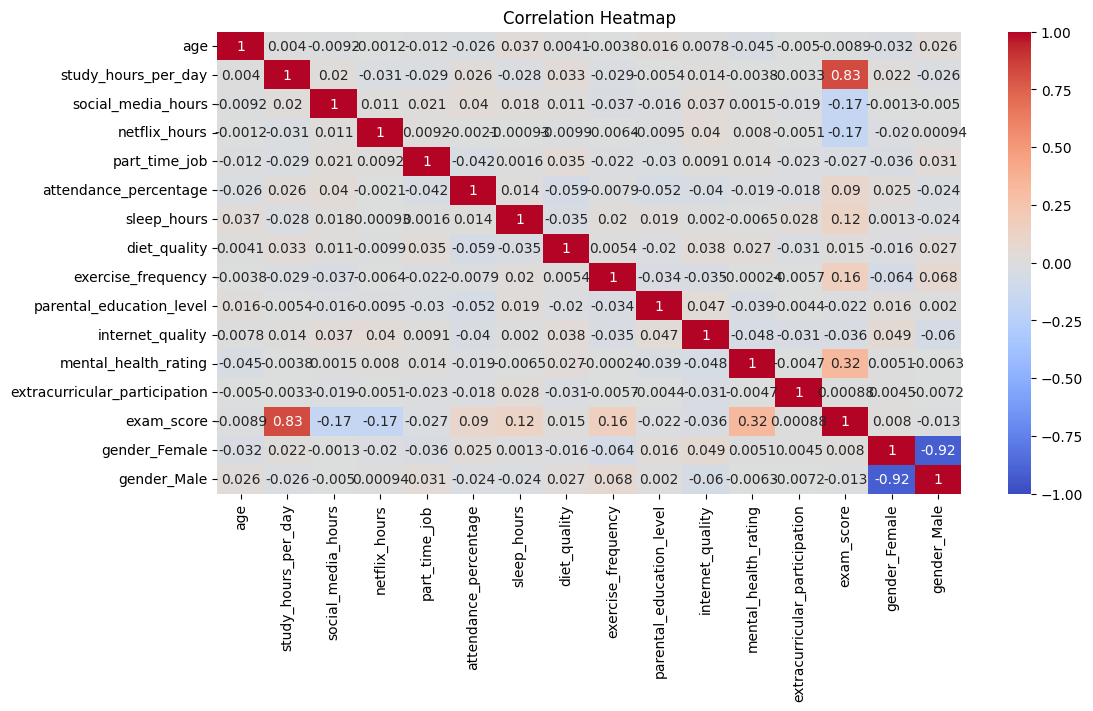

In [34]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',   
    vmin=-1, vmax=1
)
plt.title("Correlation Heatmap")

The columns/featuers those contribute very less.
1. gender_female
2. gender_male
3. neatflix_hours
4. social_media_hours
5. Parentel education level
6. internet quality

In [35]:
df.columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score',
       'gender_Female', 'gender_Male'],
      dtype='object')

In [36]:
# Droping some unuseful featuers to reduce columns.
df.drop(columns = ['social_media_hours', 
                   'netflix_hours', 
                   'internet_quality', 
                   'parental_education_level',
                   'gender_Male',
                   'gender_Female',
                  'age',
                  'part_time_job'],
        inplace = True)

In [37]:
df.shape

(1000, 8)

In [38]:
df.columns

Index(['study_hours_per_day', 'attendance_percentage', 'sleep_hours',
       'diet_quality', 'exercise_frequency', 'mental_health_rating',
       'extracurricular_participation', 'exam_score'],
      dtype='object')

In [39]:
corr_matrix = df.corr(numeric_only=True)

Text(0.5, 1.0, 'Correlation Heatmap - 2')

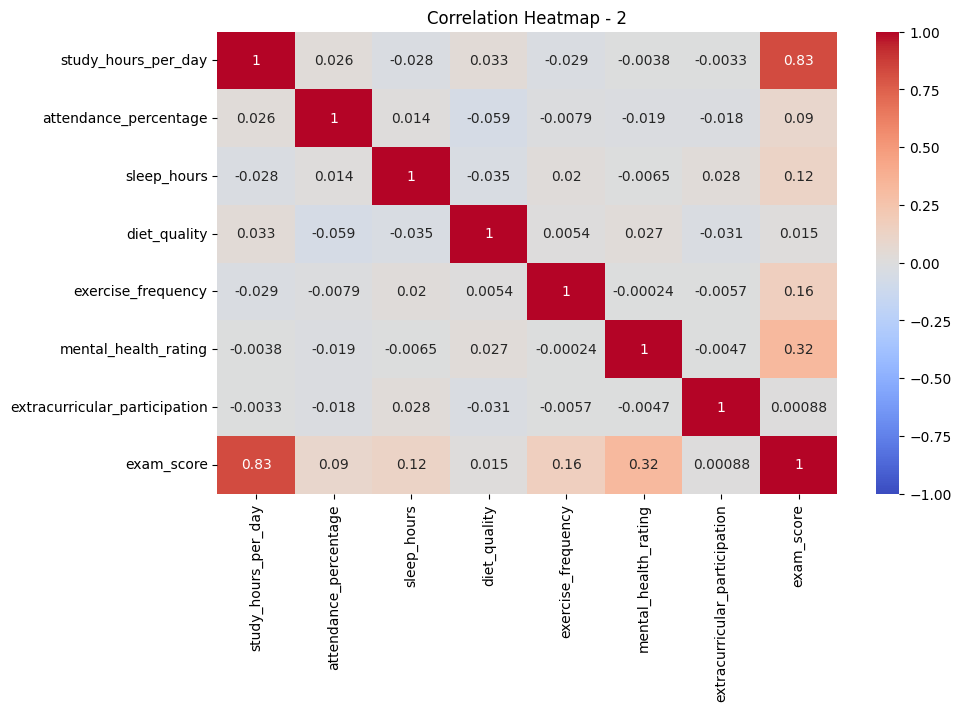

In [42]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',   
    vmin=-1, vmax=1
)
plt.title("Correlation Heatmap - 2")

## Cleane data
Now the data is cleane short and highly correlated with target features.

In [43]:
# df.to_csv("cleane.csv", index=False)